# 1. Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.preprocessing import load_dataset

# Set a consistent plotting style
sns.set_theme(style="whitegrid")

# 2. Load Dataset

In [15]:
X, y, feature_names, lb, le, df = load_dataset()
print("Dataset loaded successfully.")

[SUCCESS] Loaded Dataset: 1014 records[cite: 1].
Dataset loaded successfully.


# 3. Dataset Overview
## Dataset Shape

In [16]:
df.shape

(1014, 7)

## Sample Data

In [17]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


## Dataset Information

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 55.6 KB


## Statistical Summary

In [19]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


# 4. Target Variable Analysis
## Class Counts

In [20]:
df['RiskLevel'].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

## Class Distribution Plot

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10884\3288882154.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='RiskLevel', order=['low risk', 'mid risk', 'high risk'], palette='viridis')


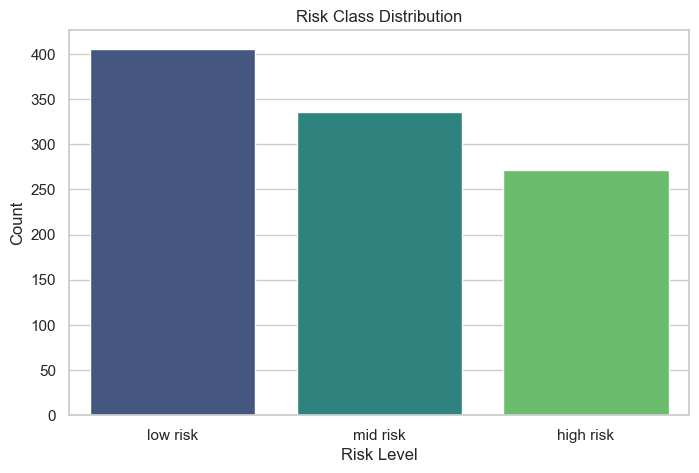

In [21]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='RiskLevel', order=['low risk', 'mid risk', 'high risk'], palette='viridis')
plt.title('Risk Class Distribution')
plt.ylabel('Count')
plt.xlabel('Risk Level')
plt.show()

# 5. Feature Distribution Analysis
## Feature Histograms

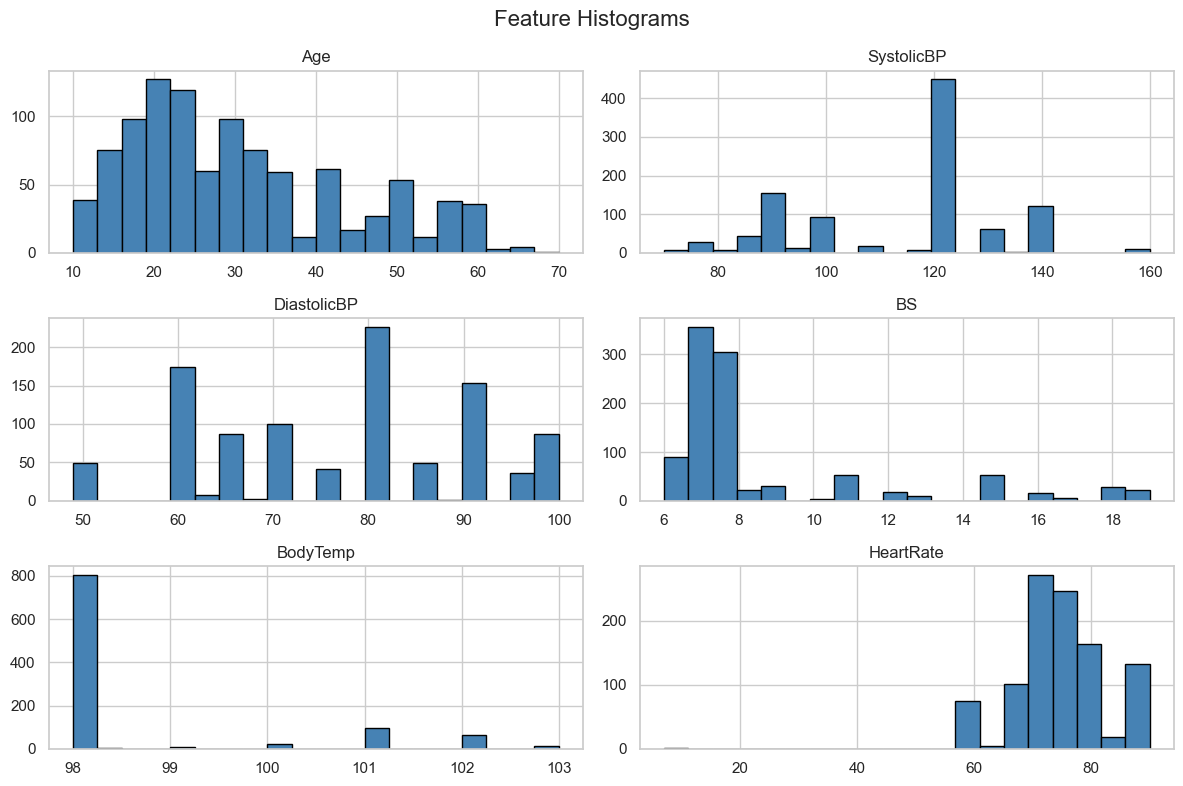

In [22]:
df.drop(columns=['RiskLevel']).hist(bins=20, figsize=(12, 8), color='steelblue', edgecolor='black')
plt.suptitle('Feature Histograms', fontsize=16)
plt.tight_layout()
plt.show()

# 5. Correlation Analysis
## Correlation Matrix

In [23]:
corr_matrix = df.drop(columns=['RiskLevel']).corr()
corr_matrix

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
Age,1.000000,0.416045,0.398026,0.473284,-0.255323,0.079798
SystolicBP,0.416045,1.000000,0.787006,0.425172,-0.286616,-0.023108
DiastolicBP,0.398026,0.787006,1.000000,0.423824,-0.257538,-0.046151
BS,0.473284,0.425172,0.423824,1.000000,-0.103493,0.142867
BodyTemp,-0.255323,-0.286616,-0.257538,-0.103493,1.000000,0.098771
HeartRate,0.079798,-0.023108,-0.046151,0.142867,0.098771,1.000000


## Correlation Heatmap

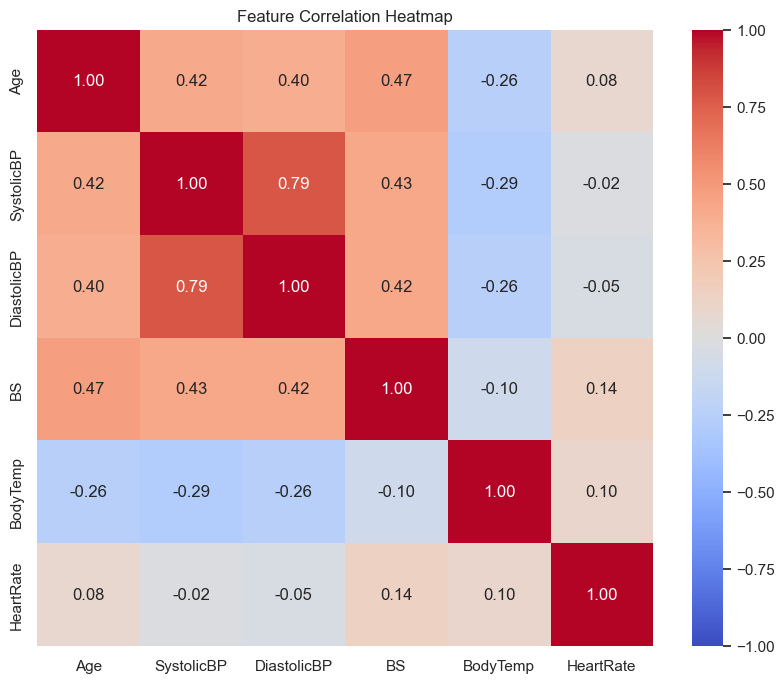

In [24]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Feature Correlation Heatmap')
plt.show()

# 7. EDA Summary

- **Dataset Size**: The dataset contains 1014 records.
- **Clinical Features**: There are 6 clinical features: Age, SystolicBP, DiastolicBP, BS, BodyTemp, and HeartRate.
- **Target Classes**: The target variable is `RiskLevel`, consisting of 'low risk', 'mid risk', and 'high risk'.
- **Class Distribution Observations**: The classes are somewhat imbalanced, with 'low risk' being the majority class and 'high risk' being the minority class.
- **Important Findings**: 
  - Features like BS and Age have notable variance and some outliers as seen in the boxplots.
  - SystolicBP and DiastolicBP are highly correlated, which is expected clinically.
  
Note: The dataset represents the pristine, clean baseline condition. Missing values and noisy conditions will be introduced later during the robustness evaluation experiments.